# Day 12: House Price Prediction using Linear Regression

In this notebook, we will:
1. Load a house price dataset
2. Perform Exploratory Data Analysis
3. Build a Linear Regression model using scikit-learn
4. Evaluate the model using different metrics (MAE, MSE, RMSE, R² Score)
5. Understand what each evaluation metric means and when to use it

## 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [ ]:
df = pd.read_csv('house_prices.csv')
print("Shape of dataset:", df.shape)
# print("\nFirst 5 rows:")
df.head()

In [3]:
print("Dataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       50 non-null     int64
 1   Bedrooms   50 non-null     int64
 2   Bathrooms  50 non-null     int64
 3   Stories    50 non-null     int64
 4   Parking    50 non-null     int64
 5   Age        50 non-null     int64
 6   Price      50 non-null     int64
dtypes: int64(7)
memory usage: 2.9 KB
None


In [4]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Price
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000
mean,2139.800000,3.480000,2.400000,2.260000,1.780000,6.42000,62700.000000
std,694.531085,1.073617,0.880631,0.876216,0.840068,4.09624,25408.700101
min,1050.000000,1.000000,1.000000,1.000000,0.000000,1.00000,25000.000000
25%,1585.000000,3.000000,2.000000,2.000000,1.000000,3.25000,44250.000000
50%,2065.000000,3.000000,2.000000,2.000000,2.000000,5.50000,58500.000000
75%,2637.500000,4.000000,3.000000,3.000000,2.000000,8.75000,77500.000000
max,3600.000000,6.000000,4.000000,4.000000,3.000000,18.00000,120000.000000


## 3. Exploratory Data Analysis (EDA)

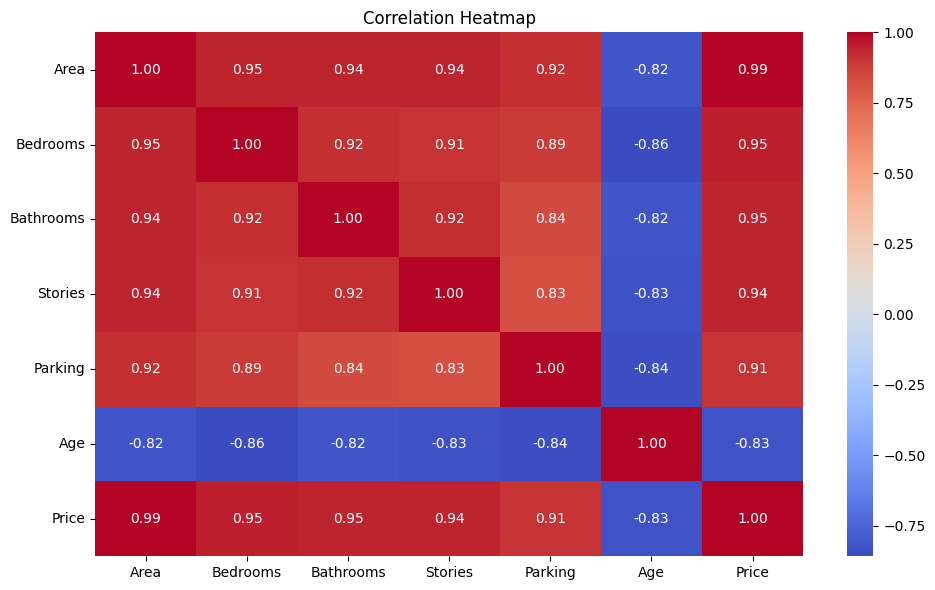

In [5]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

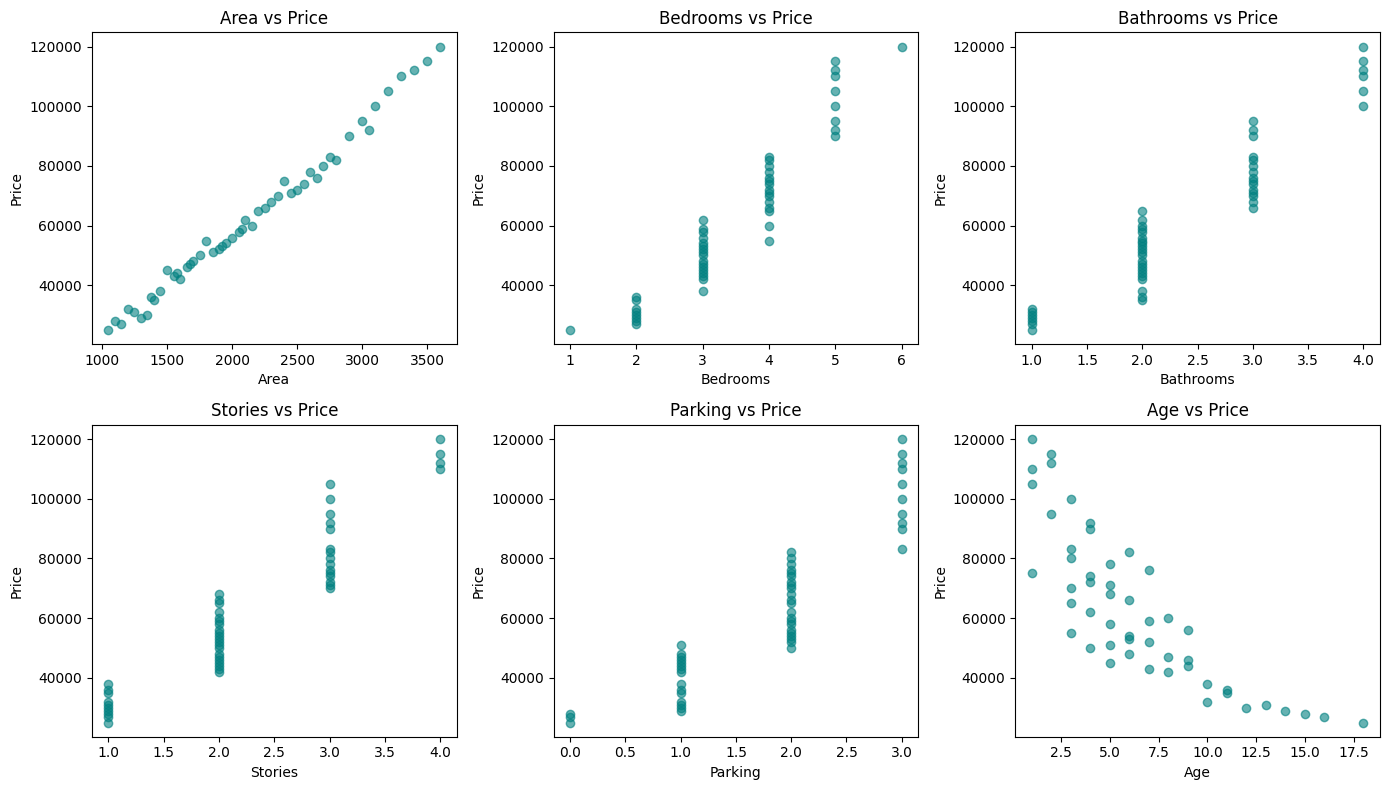

In [6]:
# Scatter plots of features vs Price
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age']

for i, feature in enumerate(features):
    row, col = i // 3, i % 3
    axes[row, col].scatter(df[feature], df['Price'], alpha=0.6, color='teal')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Price')
    axes[row, col].set_title(f'{feature} vs Price')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Train-Test Split

In [7]:
# Separate features and target
X = df.drop('Price', axis=1)
y = df['Price']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Features (X) shape: (50, 6)
Target (y) shape: (50,)

Training set size: 40
Testing set size: 10


## 5. Build Linear Regression Model

In [8]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Display model parameters
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"\nIntercept: {model.intercept_:.2f}")

Model Coefficients:
  Area: 30.16
  Bedrooms: 1737.07
  Bathrooms: 1306.35
  Stories: 1457.74
  Parking: 139.64
  Age: -8.07

Intercept: -14349.80


## 6. Make Predictions

In [9]:
# Predict on test data
y_pred = model.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)})
comparison['Difference'] = (comparison['Actual'] - comparison['Predicted']).round(2)
print("Actual vs Predicted Prices:")
comparison

Actual vs Predicted Prices:


,Actual,Predicted,Difference
0,105000,100863.76,4136.24
1,74000,78051.12,-4051.12
2,29000,31125.83,-2125.83
3,83000,84231.25,-1231.25
4,35000,35472.60,-472.60
5,44000,44112.73,-112.73
6,60000,63189.91,-3189.91
7,54000,55436.56,-1436.56
8,50000,49420.28,579.72
9,43000,43224.00,-224.00


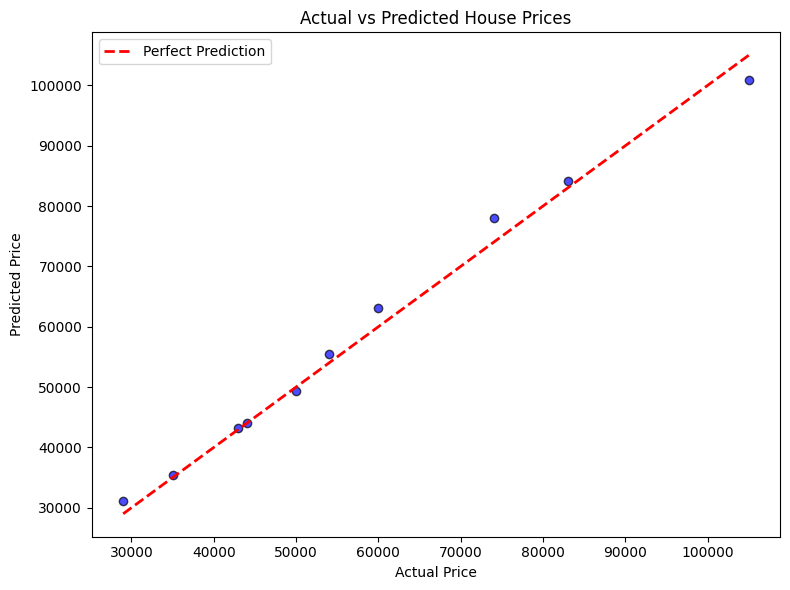

In [11]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--',
          lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Evaluation Metrics

Now let's evaluate our model using different metrics. Each metric tells us something different about our model's performance.

---

### 7.1 Mean Absolute Error (MAE)

**Formula:**

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**Explanation:**
- MAE calculates the **average of absolute differences** between predicted and actual values.
- It tells us how far off our predictions are **on average**.
- **Unit**: Same as the target variable (e.g., dollars for house prices).
- **Interpretation**: Lower MAE = Better model. A MAE of 5000 means predictions are off by $5000 on average.
- **Advantage**: Easy to understand and interpret.
- **Disadvantage**: Treats all errors equally (doesn't penalize large errors more).

In [12]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"\nInterpretation: On average, our predictions are off by ${mae:.2f} from the actual house price.")

Mean Absolute Error (MAE): 1756.00

Interpretation: On average, our predictions are off by $1756.00 from the actual house price.


---

### 7.2 Mean Squared Error (MSE)

**Formula:**

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Explanation:**
- MSE calculates the **average of squared differences** between predicted and actual values.
- It **penalizes larger errors more heavily** than smaller errors (because errors are squared).
- **Unit**: Square of the target variable's unit (e.g., dollars²).
- **Interpretation**: Lower MSE = Better model. However, it's harder to interpret directly because of squared units.
- **Advantage**: Penalizes outliers/large errors more, useful when large errors are particularly undesirable.
- **Disadvantage**: Not in the same unit as target variable, harder to interpret directly.

In [13]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"\nInterpretation: The average squared error is {mse:.2f}.")
print("MSE penalizes larger errors more heavily than MAE.")

Mean Squared Error (MSE): 5241677.92

Interpretation: The average squared error is 5241677.92.
MSE penalizes larger errors more heavily than MAE.


---

### 7.3 Root Mean Squared Error (RMSE)

**Formula:**

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2} = \sqrt{MSE}$$

**Explanation:**
- RMSE is the **square root of MSE**, bringing the error back to the **same unit** as the target variable.
- It still **penalizes large errors** more than MAE (inherited from MSE).
- **Unit**: Same as the target variable (e.g., dollars).
- **Interpretation**: Lower RMSE = Better model. More interpretable than MSE since it's in the original units.
- **Advantage**: Same unit as target, penalizes large errors, widely used in practice.
- **Disadvantage**: Still sensitive to outliers.

In [14]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"\nInterpretation: On average, our predictions deviate by ${rmse:.2f} from actual prices.")
print("RMSE is always >= MAE. If RMSE >> MAE, it indicates some large errors exist.")

Root Mean Squared Error (RMSE): 2289.47

Interpretation: On average, our predictions deviate by $2289.47 from actual prices.
RMSE is always >= MAE. If RMSE >> MAE, it indicates some large errors exist.


---

### 7.4 R² Score (Coefficient of Determination)

**Formula:**

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2} = 1 - \frac{SS_{res}}{SS_{tot}}$$

**Explanation:**
- R² tells us the **proportion of variance** in the target variable that is explained by the model.
- **Range**: Usually between 0 and 1 (can be negative for very bad models).
  - **R² = 1**: Perfect prediction (model explains 100% of variance)
  - **R² = 0**: Model is no better than simply predicting the mean
  - **R² < 0**: Model is worse than predicting the mean
- **Unit**: Dimensionless (it's a ratio).
- **Advantage**: Normalized metric (0 to 1), easy to compare across different datasets.
- **Disadvantage**: Can be misleading for non-linear relationships, doesn't tell about individual prediction accuracy.

In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation: Our model explains {r2*100:.2f}% of the variance in house prices.")
print("The remaining", f"{(1-r2)*100:.2f}% is unexplained (due to other factors or noise).")

---

## 8. Summary of All Evaluation Metrics

In [ ]:
# Summary table of all metrics
metrics_summary = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [f'{mae:.2f}', f'{mse:.2f}', f'{rmse:.2f}', f'{r2:.4f}'],
    'Unit': ['Same as target ($)', 'Squared ($²)', 'Same as target ($)', 'Dimensionless (0-1)'],
    'Best Value': ['0', '0', '0', '1'],
    'Penalizes Large Errors?': ['No (equal weight)', 'Yes (squared)', 'Yes (squared)', 'N/A']
})

print("=" * 70)
print("         MODEL EVALUATION METRICS SUMMARY")
print("=" * 70)
print(metrics_summary.to_string(index=False))
print("=" * 70)

## 9. Residual Analysis

In [ ]:
# Residual Plot
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.7, color='purple', edgecolors='black')
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')

# Distribution of Residuals
axes[1].hist(residuals, bins=8, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

---

## 10. When to Use Which Metric?

| Metric | Use When |
|--------|----------|
| **MAE** | You want an easily interpretable error in original units. All errors matter equally. |
| **MSE** | Large errors are particularly undesirable and should be penalized more. Used in optimization. |
| **RMSE** | You want interpretable units like MAE but also want to penalize large errors like MSE. |
| **R² Score** | You want to know what proportion of variance your model explains. Good for comparing models. |

---

## Conclusion

- We built a **Linear Regression** model to predict house prices based on features like Area, Bedrooms, Bathrooms, Stories, Parking, and Age.
- The model's performance was evaluated using **4 key metrics**: MAE, MSE, RMSE, and R² Score.
- Each metric provides a different perspective on model performance — use them together for a complete picture.